# 🚗 Used Car Price Prediction

## Final Project – Data Science & Machine Learning

# 1. Scope & Objectives 
* **Problem Framing:** The used car market is highly volatile. This project aims to build a predictive model to estimate car prices accurately, reducing uncertainty for buyers and sellers.
* **Declared Deliverables:** A cleaned dataset, a visual EDA report, a tuned Machine Learning pipeline, and a feature importance analysis.
* **Relevance:** This project answers critical business questions: "Which vehicle attributes most affect resale value?" and "How precisely can we automate valuations?"

# 2. Data & Governance

This dataset contains 2840 records of used cars from 2000 to 2024, obtained from Kaggle.
It is used for predicting car prices based on key vehicle features such as name, year, miles, color, condition, and price.

* **Data Sources:** The dataset is the Truecars Dataset from Kaggle, containing thousands of real-world car listings.
* **Licensing & Traceability:** Used under Apache License 2.0. All preprocessing steps are documented to ensure data lineage and transparency.

In [40]:
import pandas as pd 
import numpy as np
dataset = pd.read_csv('car_web_scraped_dataset.csv')

In [41]:
dataset.head()

,name,year,miles,color,condition,price
0,Kia Forte,2022,"41,406 miles","Gray exterior, Black interior","No accidents reported, 1 Owner","$15,988"
1,Chevrolet Silverado 1500,2021,"15,138 miles","White exterior, Black interior","1 accident reported, 1 Owner","$38,008"
2,Toyota RAV4,2022,"32,879 miles","Silver exterior, Unknown interior","No accidents reported, 1 Owner","$24,988"
3,Honda Civic,2020,"37,190 miles","Blue exterior, Black interior","No accidents reported, 1 Owner","$18,998"
4,Honda Civic,2020,"27,496 miles","Black exterior, Black interior","No accidents reported, 1 Owner","$19,498"


In [42]:
dataset.shape

(2840, 6)

In [43]:
dataset.columns

Index(['name', 'year', 'miles', 'color', 'condition', 'price'], dtype='object')

In [44]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2840 entries, 0 to 2839
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       2840 non-null   object
 1   year       2840 non-null   int64 
 2   miles      2840 non-null   object
 3   color      2840 non-null   object
 4   condition  2840 non-null   object
 5   price      2840 non-null   object
dtypes: int64(1), object(5)
memory usage: 133.3+ KB


# 3. Data Cleaning

The goal of the data cleaning step is to prepare the dataset for analysis and machine learning by handling missing values, correcting data types, and extracting useful features from raw text columns.

In [45]:
df_clean = dataset

**Convert the year variable into vehicle age**

In [46]:
df_clean["car_age"]= 2026 - df_clean["year"]


**miles : converted from string to integer**

In [47]:
df_clean["miles"] = df_clean["miles"].str.strip("miles").str.replace(",", "").astype(int)
df_clean["miles"]

0        41406
1        15138
2        32879
3        37190
4        27496
         ...  
2835     98601
2836    120694
2837     27894
2838     50220
2839     26510
Name: miles, Length: 2840, dtype: int64

**price : converted from string to numerical (integer) format**

In [48]:
df_clean['price'] = df_clean['price'].str.strip('$').str.replace(',','').astype(int)
df_clean['price']

0       15988
1       38008
2       24988
3       18998
4       19498
        ...  
2835     8995
2836     9495
2837    29999
2838    22992
2839    24135
Name: price, Length: 2840, dtype: int64

**Extract brand and model from the name column**

In [49]:
df_clean[['brand', 'model']] = df_clean['name'].str.split(' ', n=1, expand=True)


**Extract interior color and exterior color  from the name column**

In [50]:
df_clean[["color_exterior", "color_interior"]] = df_clean["color"].astype(str).str.lower().str.split(',', expand=True)
df_clean["color_exterior"] = df_clean["color_exterior"].str.replace("exterior", '', regex=False).str.strip()

df_clean["color_interior"] = df_clean["color_interior"].str.replace("interior", '', regex=False).str.strip()


**Extract num_accidents and num_owners  from the condition column**

In [51]:
df_clean[['num_accidents','num_owners']]= df_clean['condition'].str.split(',', expand = True)
df_clean['num_accidents'] = df_clean['num_accidents'].str.extract(r'(\d+)').fillna(0).astype(int)
df_clean['num_owners'] = df_clean['num_owners'].str.extract(r'(\d+)').astype(int)


In [52]:
df_clean['num_owners'].value_counts()

num_owners
1    1863
2     618
3     244
4      72
5      25
0      13
7       3
8       2
Name: count, dtype: int64

In [53]:
df_clean["num_owners"] = (
    df_clean["num_owners"]
    .replace(0, np.nan)
    .fillna(1)
    .astype(int)
)

In [54]:
df_clean['num_owners'].value_counts()

num_owners
1    1876
2     618
3     244
4      72
5      25
7       3
8       2
Name: count, dtype: int64

In [55]:
df_clean['model'].value_counts()

model
Corolla              114
Civic                 97
C-Class               76
Camry                 69
F-150                 65
                    ... 
Q70                    1
Cruze Limited          1
720S                   1
GR Supra               1
Atlas Cross Sport      1
Name: count, Length: 309, dtype: int64

**Grouping rare car models into the "Other" category.**
* Reduce dimensionality
* Avoid overfitting
* Improve model stability

In [56]:
model_counts = df_clean["model"].value_counts()

valid_models = model_counts[
    model_counts >= 10
].index

df_clean["model"] = df_clean["model"].apply(
    lambda x: x if x in valid_models else "Other"
)

**Remove the repeated columns**

In [57]:
df_clean = df_clean.drop('name', axis=1)
df_clean = df_clean.drop('color', axis=1)
df_clean = df_clean.drop('condition', axis=1)
df_clean = df_clean.drop('year', axis=1)


**Replace Unknown Values**

In [58]:
df_clean = df_clean.replace(
    ['unknown', 'Unknown', 'UNKNOWN', ' '],
    np.nan
)

**Check missing values**

In [59]:
print("\nMissing values")
df_clean.isnull().sum()


Missing values


miles               0
price               0
car_age             0
brand               0
model               0
color_exterior     28
color_interior    162
num_accidents       0
num_owners          0
dtype: int64

In [60]:
df_clean

,miles,price,car_age,brand,model,color_exterior,color_interior,num_accidents,num_owners
0,41406,15988,4,Kia,Forte,gray,black,0,1
1,15138,38008,5,Chevrolet,Silverado 1500,white,black,1,1
2,32879,24988,4,Toyota,RAV4,silver,NaN,0,1
3,37190,18998,6,Honda,Civic,blue,black,0,1
4,27496,19498,6,Honda,Civic,black,black,0,1
...,...,...,...,...,...,...,...,...,...
2835,98601,8995,13,Ford,Escape,silver,NaN,2,3
2836,120694,9495,17,Mercedes-Benz,Other,black,black,1,3
2837,27894,29999,4,Mercedes-Benz,GLC,gray,gray,0,2
2838,50220,22992,5,Honda,CR-V,gray,NaN,0,1


In [61]:
df_clean.describe()

,miles,price,car_age,num_accidents,num_owners
count,2840.000,2840.000,2840.000,2840.000,2840.000
mean,50138.446,25745.427,7.166,0.279,1.512
std,36482.440,13627.610,3.558,0.599,0.861
min,25.000,4395.000,2.000,0.000,1.000
25%,23233.750,17851.000,5.000,0.000,1.000
50%,41076.000,23000.000,6.000,0.000,1.000
75%,70978.250,31222.500,9.000,0.000,2.000
max,307292.000,252900.000,26.000,5.000,8.000


In [62]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2840 entries, 0 to 2839
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   miles           2840 non-null   int64 
 1   price           2840 non-null   int64 
 2   car_age         2840 non-null   int64 
 3   brand           2840 non-null   object
 4   model           2840 non-null   object
 5   color_exterior  2812 non-null   object
 6   color_interior  2678 non-null   object
 7   num_accidents   2840 non-null   int64 
 8   num_owners      2840 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 199.8+ KB


our preprocessing, cleaning and formatting is now finished. the next step will be applying some visualizations to gain a better insight of the data at hand.

# 4. EDA (Exploratory Data Analysis)
We perform EDA to understand the distribution of prices and identify correlations between features like mileage and age. and We expect a strong negative correlation between mileage and price.



## 4.1 visualizations

<Figure size 1200x1000 with 0 Axes>

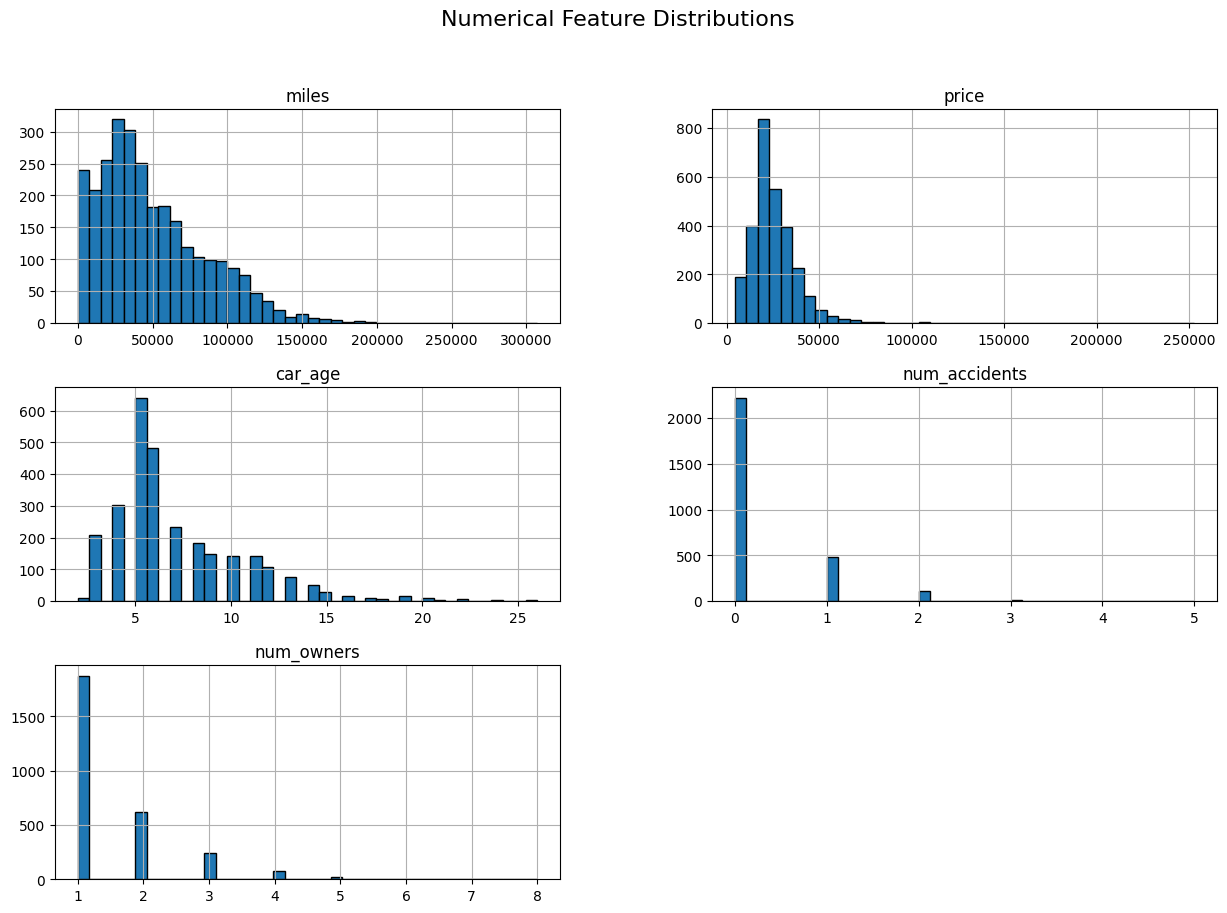

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize=(12,10))
df_clean.hist(bins=40, edgecolor='black', figsize=(15,10))
plt.suptitle("Numerical Feature Distributions", fontsize=16)
plt.show()

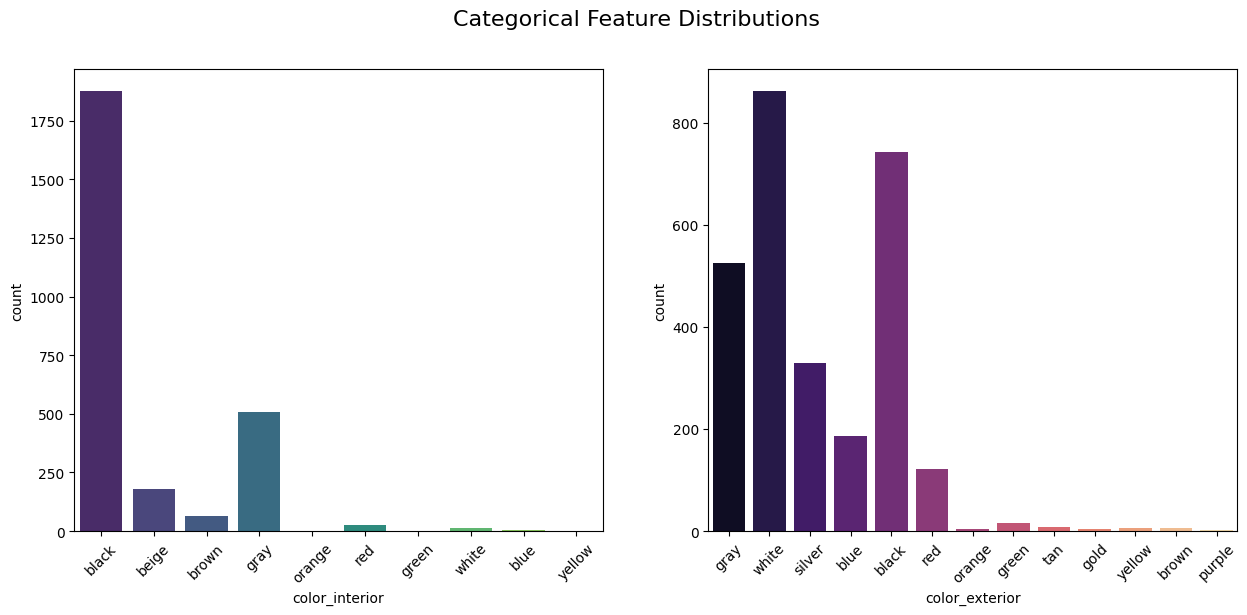

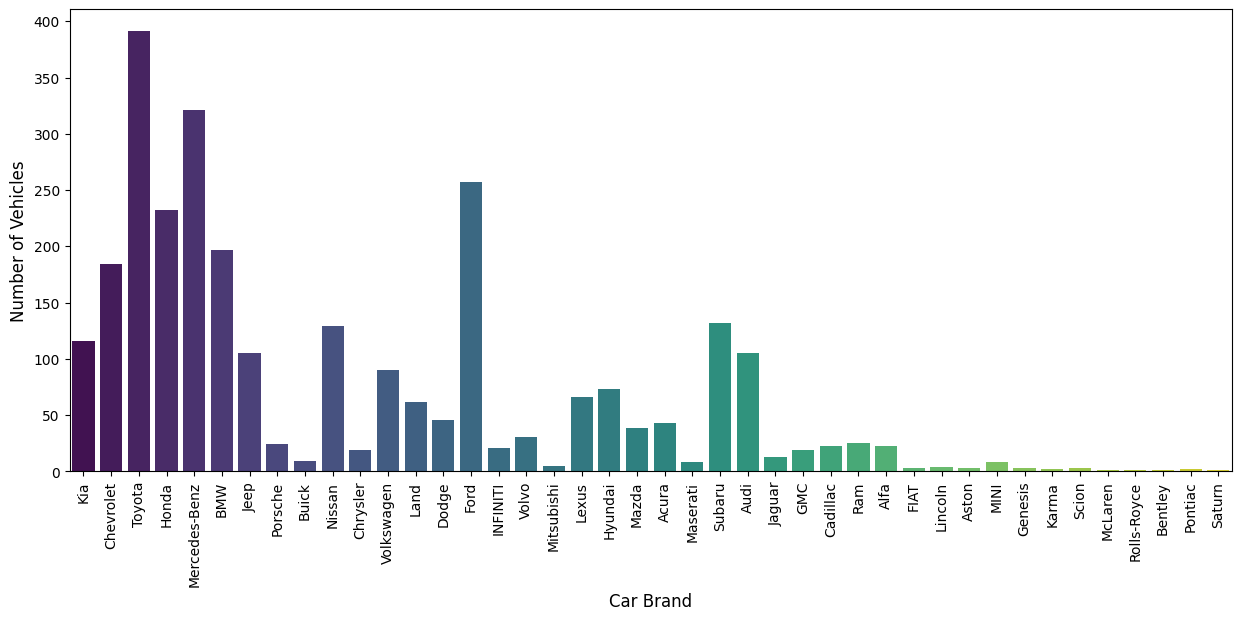

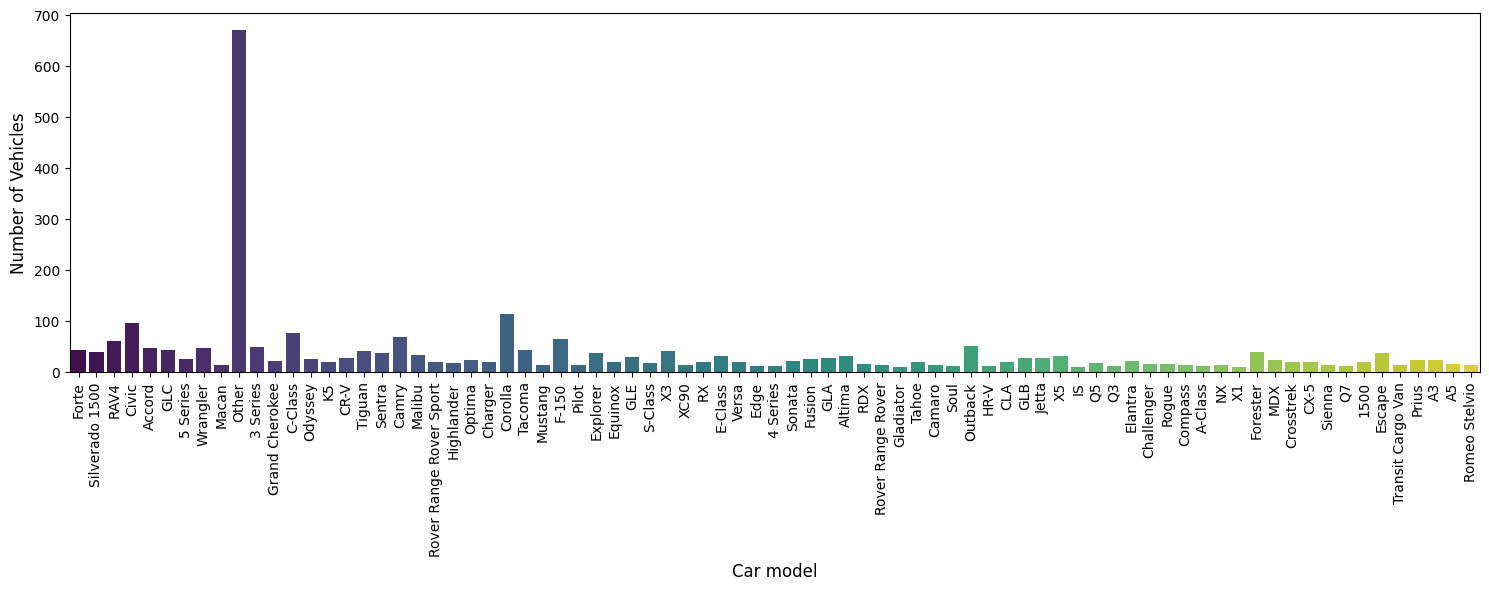

In [64]:

# Set the grid: 2 rows and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plt.suptitle("Categorical Feature Distributions", fontsize=16)

# Interior Color Distribution
sns.countplot(x="color_interior", data=df_clean, ax=axes[0], hue="color_interior", palette="viridis", legend=False)
axes[0].tick_params(axis='x', rotation=45)

# Exterior Color Distribution
sns.countplot(x="color_exterior", data=df_clean, ax=axes[1], hue="color_exterior", palette="magma", legend=False)
axes[1].tick_params(axis='x', rotation=45)


# Brand Distribution
plt.figure(figsize=(15, 6))
sns.countplot(x="brand", data=df_clean, hue="brand", palette="viridis", legend=False)
plt.xlabel("Car Brand", fontsize=12)
plt.ylabel("Number of Vehicles", fontsize=12)
plt.xticks(rotation=90)


# model Distribution
plt.figure(figsize=(15, 6))
sns.countplot(x="model", data=df_clean, hue="model", palette="viridis", legend=False)
plt.xlabel("Car model", fontsize=12)
plt.ylabel("Number of Vehicles", fontsize=12)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


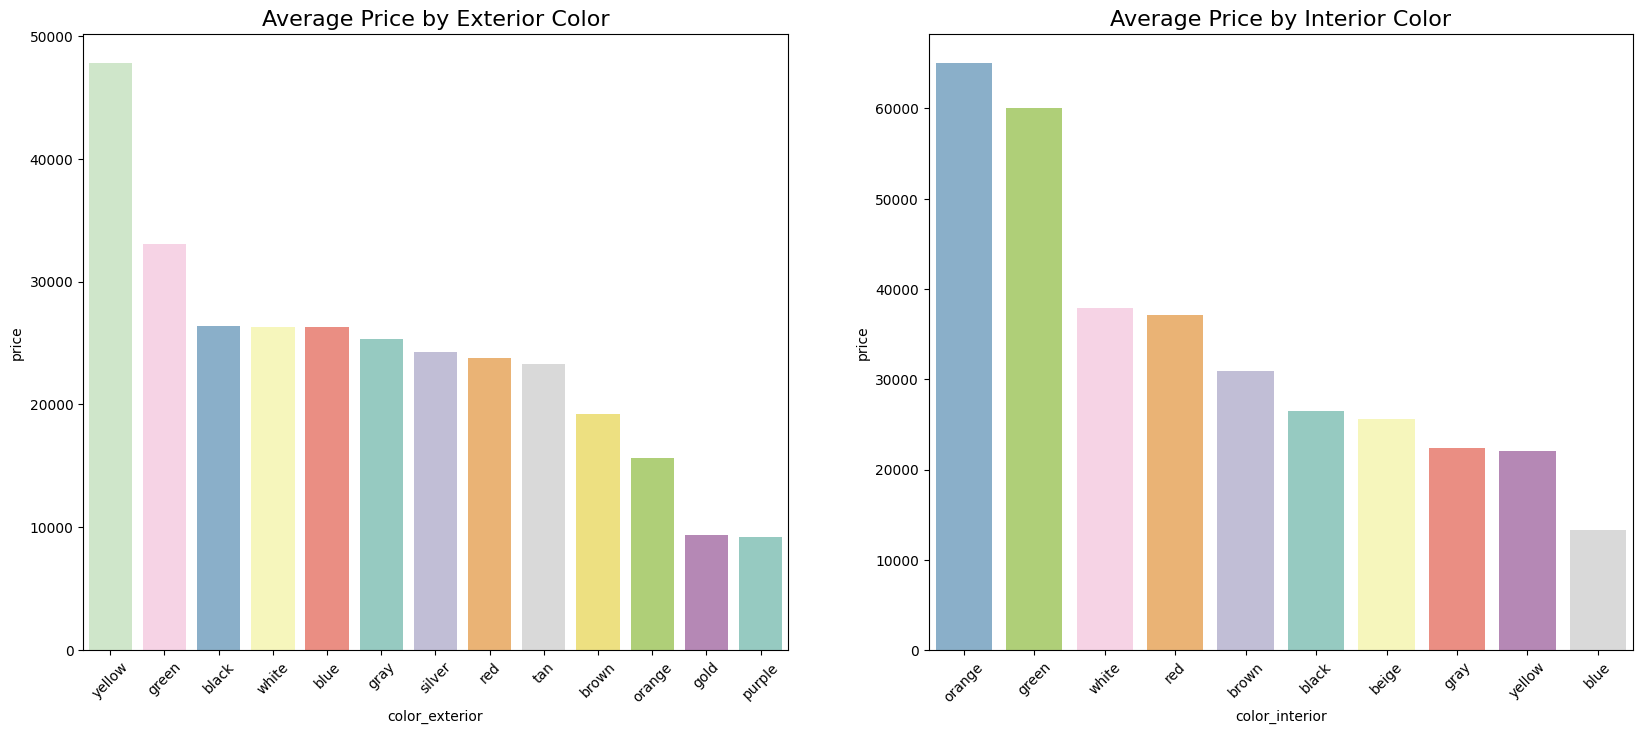

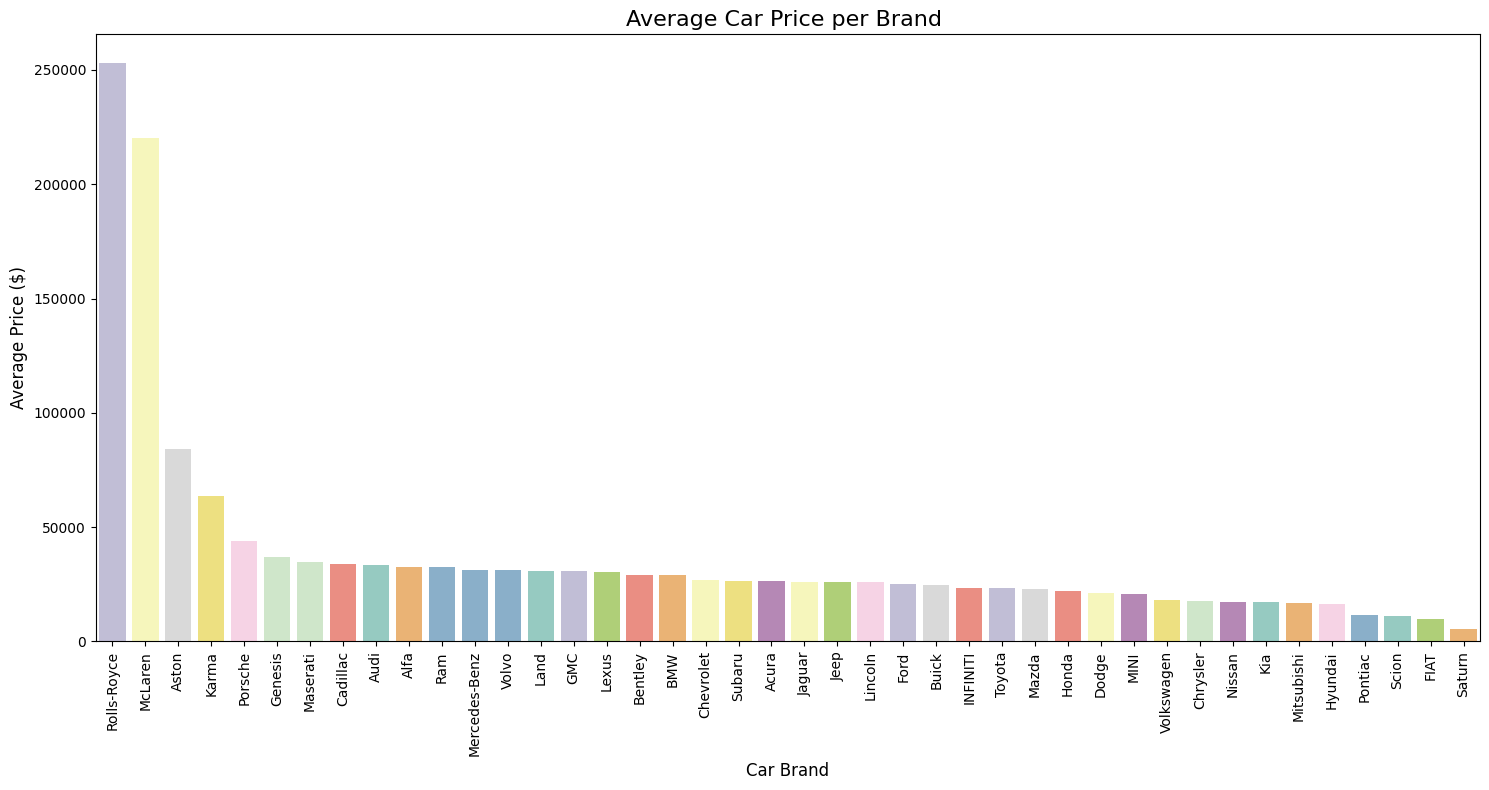

In [65]:

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Analysis for exterior color
ext_order = df_clean.groupby('color_exterior')['price'].mean().sort_values(ascending=False).index
sns.barplot(data=df_clean, x="color_exterior", y="price", order=ext_order, 
            errorbar=None, palette="Set3", hue="color_exterior", legend=False, ax=axes[0])
axes[0].set_title("Average Price by Exterior Color", fontsize=16)
axes[0].tick_params(axis='x', rotation=45)

# Analysis for interior color
int_order = df_clean.groupby('color_interior')['price'].mean().sort_values(ascending=False).index
sns.barplot(data=df_clean, x="color_interior", y="price", order=int_order, 
            errorbar=None, palette="Set3", hue="color_interior", legend=False, ax=axes[1])
axes[1].set_title("Average Price by Interior Color", fontsize=16)
axes[1].tick_params(axis='x', rotation=45)


# Calculate the mean price per brand and sort them in descending order
avg_price_per_brand = df_clean.groupby("brand")["price"].mean().sort_values(ascending=False).index

plt.figure(figsize=(15, 8))
sns.barplot(data=df_clean, x= "brand", y="price", order=avg_price_per_brand, errorbar=None, palette="Set3", hue="brand", legend=False)
# Setting Titles and Labels
plt.title("Average Car Price per Brand ", fontsize=16)
plt.xlabel("Car Brand", fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90) 

plt.tight_layout()
plt.show()

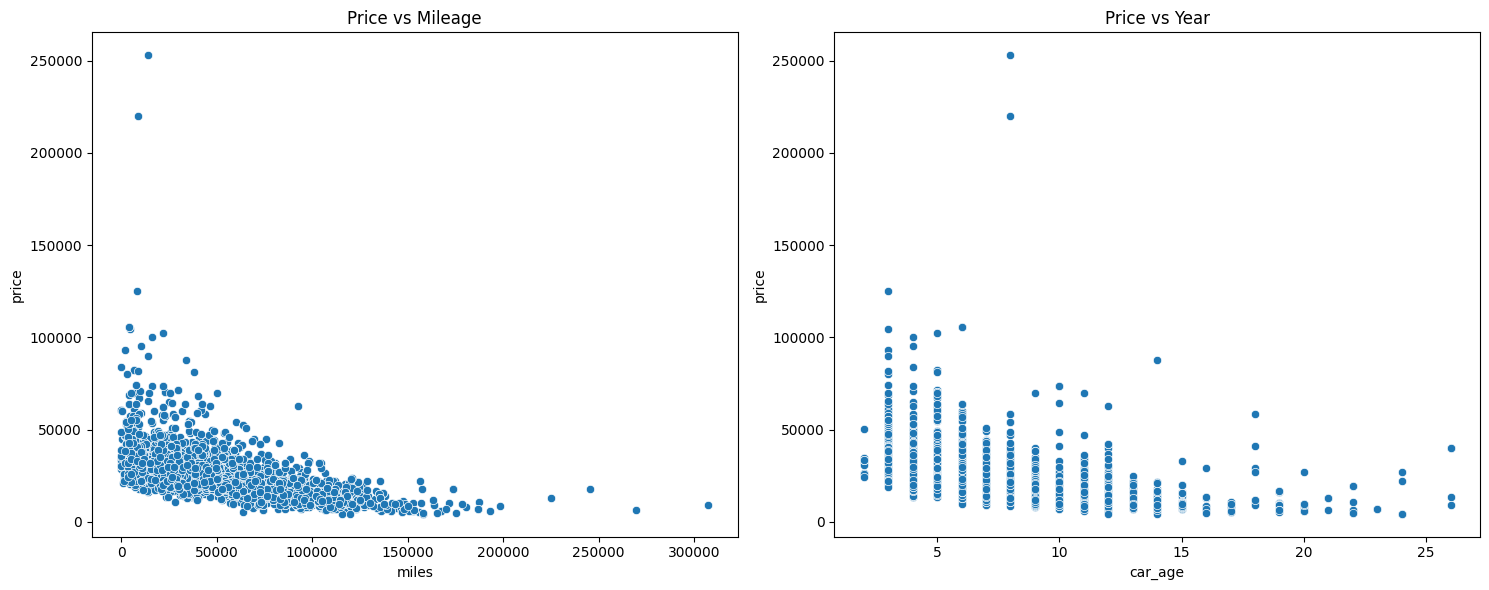

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=df_clean, x="miles", y="price", ax=axes[0])
axes[0].set_title("Price vs Mileage", fontsize=12)

sns.scatterplot(data=df_clean, x="car_age", y="price", ax=axes[1])
axes[1].set_title("Price vs Year", fontsize=12)

plt.tight_layout()
plt.show()

These two scatter plots validate our first EDA hypothesis. On the left, we see a clear negative 
correlation between mileage and price. On the right, the Car Age show the same trend: as the 
vehicle gets older, its market value depreciates. These visualizations justify why these two 
features are the primary price drivers in our Machine Learning model.

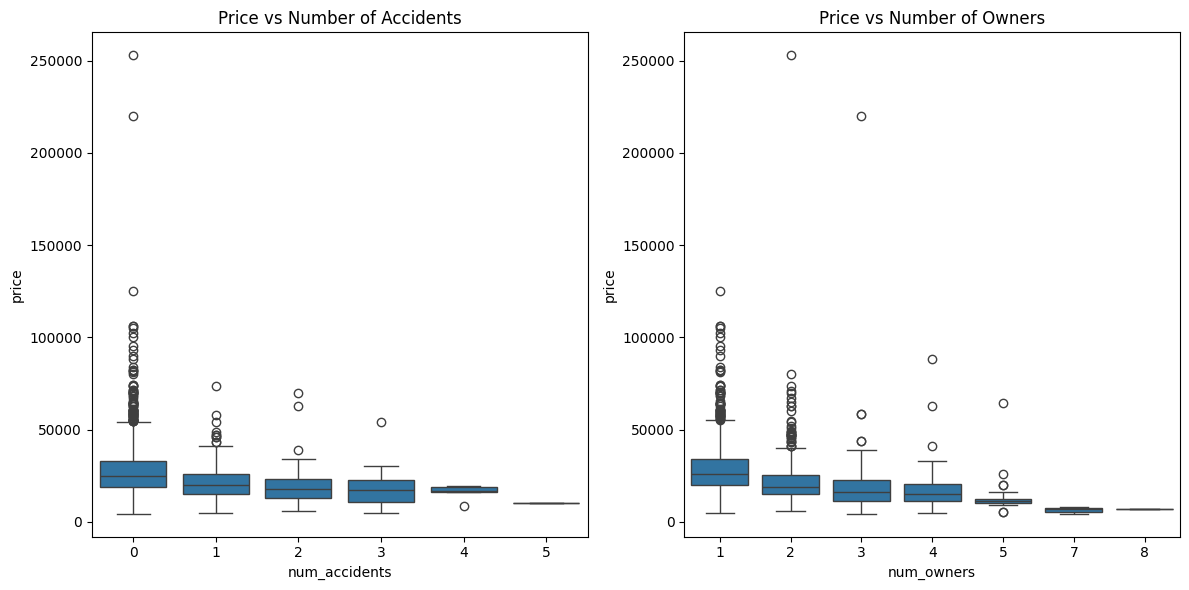

In [67]:
fig, axes = plt.subplots(1,2 , figsize=(12,6))
sns.boxplot(data=df_clean, x="num_accidents", y="price", ax= axes[0])
axes[0].set_title("Price vs Number of Accidents", fontsize=12)

sns.boxplot(data=df_clean, x="num_owners", y="price", ax= axes[1])
axes[1].set_title("Price vs Number of Owners", fontsize=12)
plt.tight_layout()
plt.show()

I used Boxplots to analyze the impact of vehicle history on price. These charts reveal a clear trend: vehicles with fewer accidents and fewer previous owners maintain a higher market value.

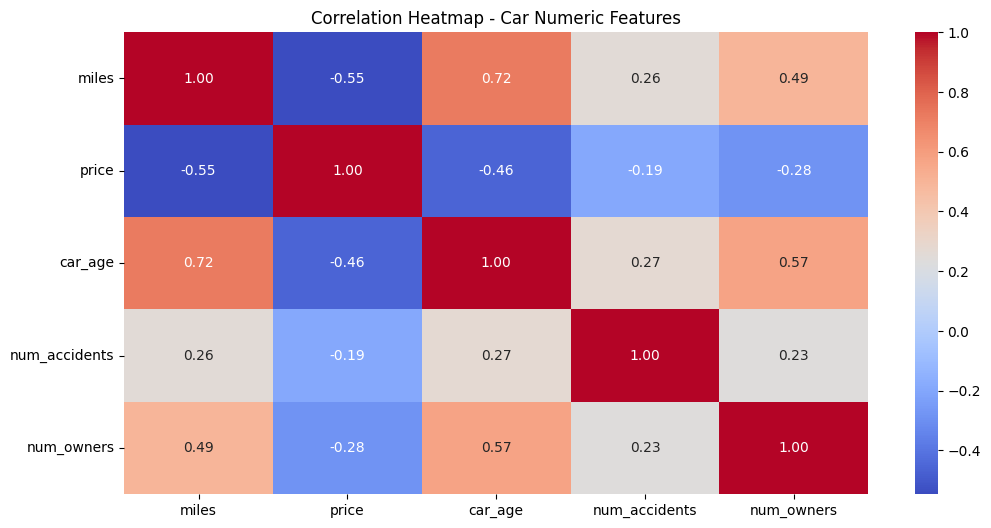

In [68]:
numeric_features = df_clean.select_dtypes(include=['int64'])

# Compute correlation matrix
corr = numeric_features.corr()
# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Car Numeric Features")
plt.show()


#### Interpretation of Correlation Results

Based on the Heatmap, we can categorize our findings into two main groups:

#### A. Primary Price Drivers (Most Important)
These features have a direct and significant impact on the car's market value:
*   **Mileage vs. Price (-0.55):** This is our strongest predictor. It shows a clear negative correlation, meaning that as mileage increases, the price drops significantly due to wear and tear.
*   **Age vs. Price (-0.46):** As expected, newer models command higher prices, and the value depreciates as the vehicle gets older.

#### B. Supporting Logical Relationships
These correlations confirm the consistency of our dataset but affect the price indirectly:
*   **Age vs. Mileage (+0.72) & Owner vs. Age (+0.57):** These strong positive correlations are logically sound. Older vehicles naturally tend to accumulate more miles and pass through more owners over time.

**Conclusion:** Our model will primarily rely on **Mileage** and **Age** to provide accurate price predictions.


# 5. Machine Learning (ML Pipeline)

### 5.1.1 Algorithm Justification 
We compared different algorithms: **Ridge Regression**, **Decision Tree**, and **Random Forest**. The Random Forest was selected as the final model because it captures non-linear relationships more effectively and achieved the best balance between accuracy and stability.

### 5.1.2 Preprocessing Workflow

To ensure model robustness and prevent **Data Leakage**, I implemented a strict preprocessing pipeline:

1. **Data Imputation:** Missing colors were filled using the **Mode** calculated strictly from the training set.
2. **Encoding & Alignment:** Categorical variables (Brand, Model, Colors) were transformed using **One-Hot Encoding**. I used **Feature Alignment** to ensure consistency between the training and testing feature spaces.


In [69]:

from sklearn.model_selection import train_test_split

# COPY DATASET
df = df_clean.copy()

# TARGET / FEATURES
X = df.drop("price", axis=1)
y = df["price"]

# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  DATA IMPUTATION 
# Impute Missing Colors
mode_color_exterior = X_train['color_exterior'].mode()[0]
mode_color_interior = X_train['color_interior'].mode()[0]

X_train['color_exterior'] = X_train['color_exterior'].fillna(mode_color_exterior)
X_test['color_exterior'] = X_test['color_exterior'].fillna(mode_color_exterior)

X_train['color_interior'] = X_train['color_interior'].fillna(mode_color_interior)
X_test['color_interior'] = X_test['color_interior'].fillna(mode_color_interior)


# ENCODING & ALIGNMENT

# 1. Define categorical columns to encode
categorical_cols = ['brand','model', 'color_exterior', 'color_interior']

# 2. Apply One-Hot Encoding separately to Train and Test sets
# drop_first=True is used to avoid the dummy variable trap (multi-collinearity)

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# 3. Align the features of the Test set with the Train set
# This ensures both datasets have the exact same columns and order
# Any category present in Test but not in Train will be dropped (join='left')
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Verify the final shape of the datasets
print(f"Training Features: {X_train.shape}")
print(f"Testing Features: {X_test.shape}")



Training Features: (2272, 143)
Testing Features: (568, 143)


## 5.2 Model Comparison and Selection

In this stage, I evaluated three different machine learning algorithms to determine which one provides the most accurate and stable price predictions for the used car market.



**1.Ridge Regression (Linear Model):**


In [70]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
#  Wrapping the steps into a Pipeline
# Step 1: 'scaler' - Standardizes numerical features (Mean=0, Std=1)
# Step 2: 'ridge' - Applies Linear Regression with L2 Regularization (alpha=1.0)

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('ridge', Ridge(alpha=1.0))   
])

R_model = ridge_pipeline

# Training the pipeline
R_model.fit(X_train, y_train)

# Making predictions 
y_test_pred_R = R_model.predict(X_test)
y_train_pred_R = R_model.predict(X_train)

# EVALUATION
mse_R = mean_squared_error(y_test, y_test_pred_R)
mae_R = mean_absolute_error(y_test, y_test_pred_R)
r2_train_R = r2_score(y_train, y_train_pred_R)
r2_test_R = r2_score(y_test, y_test_pred_R)
rmse_R = np.sqrt(mse_R)

print("\nRidge Regression")

print("\nTRAIN ")
print(f"R^2 Score train: {r2_train_R:.3f}")
print("\nTEST ")
print(f"R^2 Score test: {r2_test_R:.3f}")
print(f"MAE: ${mae_R:.2f}")
print(f"RMSE: ${rmse_R:.2f}")
print(f"Mean Squared Error: {mse_R:.3f}")



Ridge Regression

TRAIN 
R^2 Score train: 0.768

TEST 
R^2 Score test: 0.652
MAE: $4637.25
RMSE: $7423.14
Mean Squared Error: 55103071.884


**2.Decision Tree (Baseline Tree Model):**

Decision Tree

TRAIN 
R^2 Score train: 0.437

TEST 
R^2 Score test: 0.317
MAE: $7055.12
RMSE: $10405.84
Mean Squared Error: 108281535.443


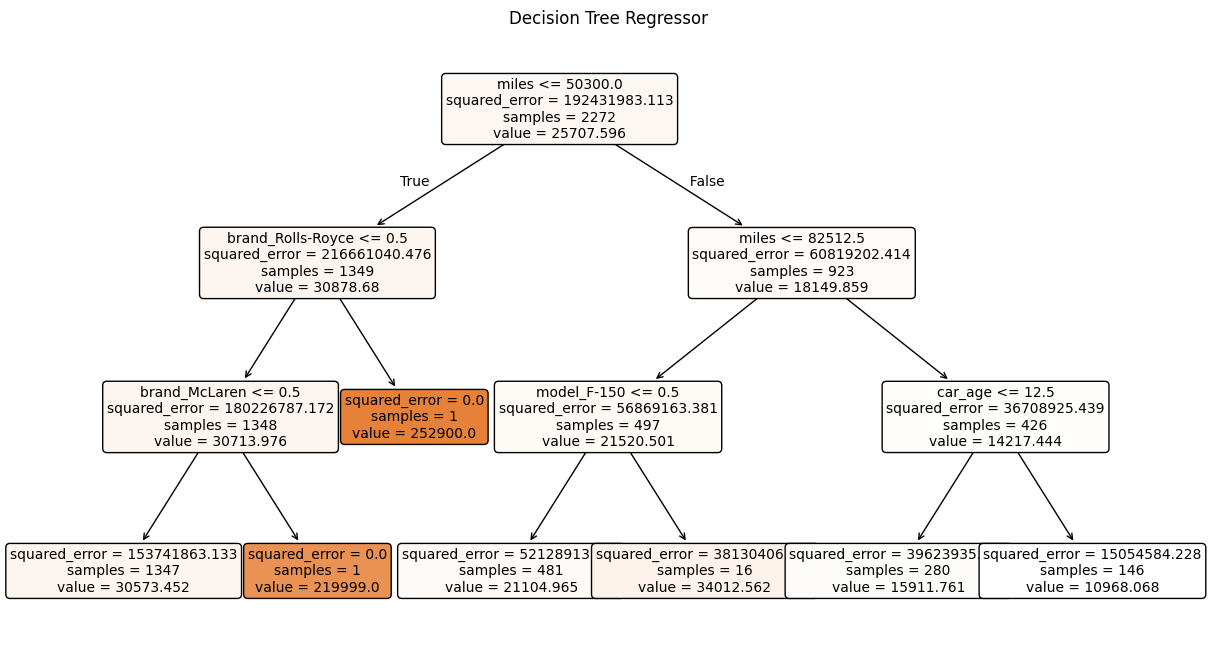

In [71]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Decision Tree
dt_model = DecisionTreeRegressor(max_depth=3,  random_state=42)
dt_model.fit(X_train, y_train)
y_test_pred_dt = dt_model.predict(X_test)
y_train_pred_dt = dt_model.predict(X_train)


# EVALUATION
mse_dt = mean_squared_error(y_test, y_test_pred_dt)
mae_dt = mean_absolute_error(y_test, y_test_pred_dt)
r2_train_dt = r2_score(y_train, y_train_pred_dt)
r2_test_dt = r2_score(y_test, y_test_pred_dt)
rmse_dt = np.sqrt(mse_dt)

print("Decision Tree")
print("\nTRAIN ")
print(f"R^2 Score train: {r2_train_dt:.3f}")
print("\nTEST ")
print(f"R^2 Score test: {r2_test_dt:.3f}")
print(f"MAE: ${mae_dt:.2f}")
print(f"RMSE: ${rmse_dt:.2f}")
print(f"Mean Squared Error: {mse_dt:.3f}")


# Plot tree
plt.figure(figsize=(15,8))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Regressor")
plt.show()


**3.Random Forest :**

In [72]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest
pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(max_depth = 50 , min_samples_leaf = 3, random_state=42))
])

pipeline_rf.fit(X_train, y_train)

y_test_pred_rf = pipeline_rf.predict(X_test)
y_train_pred_rf= pipeline_rf.predict(X_train)


# EVALUATION
mse_rf = mean_squared_error(y_test, y_test_pred_rf)
mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("\nRandom Forest")
print("\nTRAIN ")
print(f"R^2 Score train: {r2_train_rf:.3f}")
print("\nTEST ")
print(f"R^2 Score test: {r2_test_rf:.3f}")
print(f"MAE: ${mae_rf:.2f}")
print(f"RMSE: ${rmse_rf:.2f}")
print(f"Mean Squared Error: {mse_rf:.3f}")



Random Forest

TRAIN 
R^2 Score train: 0.755

TEST 
R^2 Score test: 0.670
MAE: $4534.77
RMSE: $7229.01
Mean Squared Error: 52258626.859



--- Final Model Comparison ---



,Metric,Ridge Regression,Decision Tree,Random Forest
0,R-squared (Test),0.652,0.317,0.670
1,MAE ($),4637.252,7055.117,4534.768
2,RMSE ($),7423.144,10405.841,7229.013


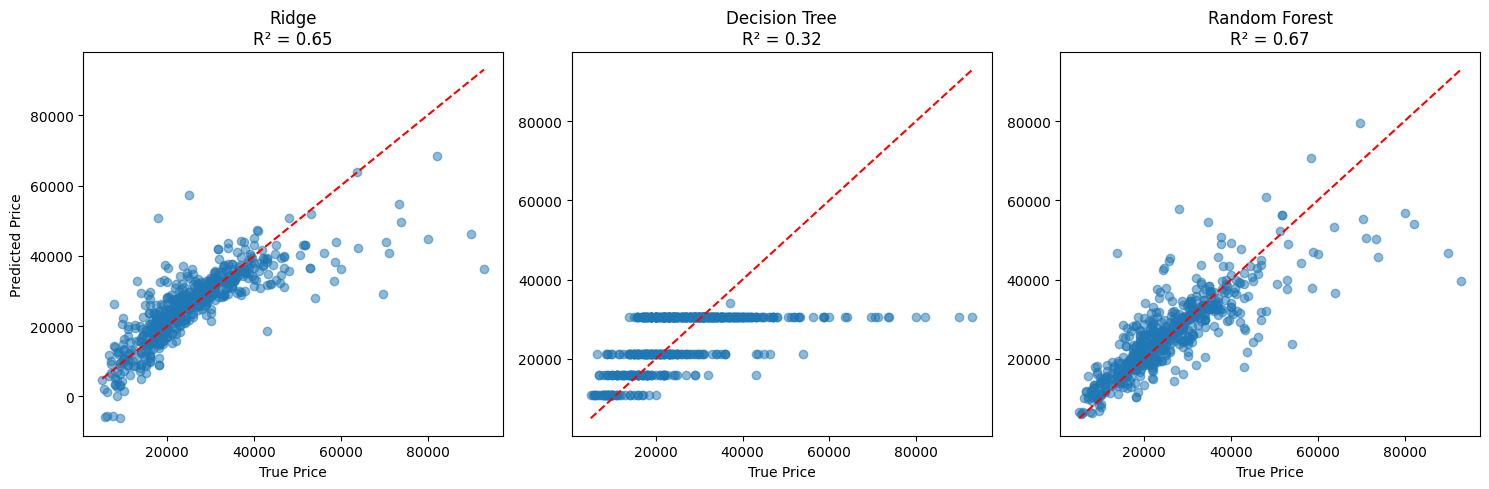

In [73]:
# Create a summary of the three models
comparison_data = {
    'Metric': ['R-squared (Test)', 'MAE ($)', 'RMSE ($)'],
    'Ridge Regression': [r2_test_R, mae_R, rmse_R],
    'Decision Tree': [r2_test_dt, mae_dt, rmse_dt],
    'Random Forest': [r2_test_rf, mae_rf, rmse_rf]
}

df_results = pd.DataFrame(comparison_data)
print("\n--- Final Model Comparison ---\n")
pd.options.display.float_format = '{:.3f}'.format
display(df_results)

print("\n")
plt.figure(figsize=(15,5))

# Ridge
plt.subplot(1,3,1)
plt.scatter(y_test, y_test_pred_R, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title(f"Ridge\nR² = {r2_test_R:.2f}")
plt.xlabel("True Price")
plt.ylabel("Predicted Price")

# Decision Tree
plt.subplot(1,3,2)
plt.scatter(y_test, y_test_pred_dt, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title(f"Decision Tree\nR² = {r2_test_dt:.2f}")
plt.xlabel("True Price")

# Random Forest
plt.subplot(1,3,3)
plt.scatter(y_test, y_test_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title(f"Random Forest\nR² = {r2_test_rf:.2f}")
plt.xlabel("True Price")

plt.tight_layout()
plt.show()



In the Random Forest plot, although it is our best model, we still see some outliers (scattered points far from the line). This is primarily due to unobserved variables in our dataset, such as the mechanical condition or extra car options that significantly affect the price. However, compared to Ridge and Decision Tree, Random Forest still maintains the tightest cluster around the ideal prediction line

## 5.3 Hyperparameter Tuning

In [74]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

# Define the parameter distributions

param_dist = {
    'model__n_estimators' : randint(300, 900),
    'model__max_depth': [None, 10, 20, 30, 50],
    'model__min_samples_leaf': randint(1, 6),
    'model__min_samples_split': randint(2, 15),
    'model__max_features': ['sqrt', 'log2', 0.7]
}


cv = KFold(n_splits=5, shuffle=True, random_state=42)

# RANDOM SEARCH

random_search = RandomizedSearchCV(
    estimator= pipeline_rf,
    param_distributions=param_dist,
    n_iter=80,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2
)


# TRAINING
# =========================
random_search.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================
best_rf = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

# Train predictions
y_train_pred_rs = best_rf.predict(X_train)
y_test_pred_rs = best_rf.predict(X_test)

# EVALUATION
mse_rs = mean_squared_error(y_test, y_test_pred_rs)
r2_train_rs = r2_score(y_train, y_train_pred_rs)
r2_test_rs = r2_score(y_test, y_test_pred_rs)

print("\nTRAIN SET")
print(f"R^2 Score train: {r2_train_rs:.3f}")

print("\nTEST SET")
print(f"R^2 Score test: {r2_test_rs:.3f}")
print(f"MAE: ${ mean_absolute_error(y_test, y_test_pred_rs):.3f}")
print(f"Mean Squared Error: {mse_rs:.3f}")
print(f"RMSE: ${np.sqrt(mse_rs):.3f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Parameters: {'model__max_depth': 50, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 427}

TRAIN SET
R^2 Score train: 0.889

TEST SET
R^2 Score test: 0.732
MAE: $3909.615
Mean Squared Error: 42401434.963
RMSE: $6511.638


We used RandomizedSearchCV to optimize the Random Forest hyperparameters, which improved the model’s performance by finding the best combination of tree depth, number of estimators, and feature selection strategy.

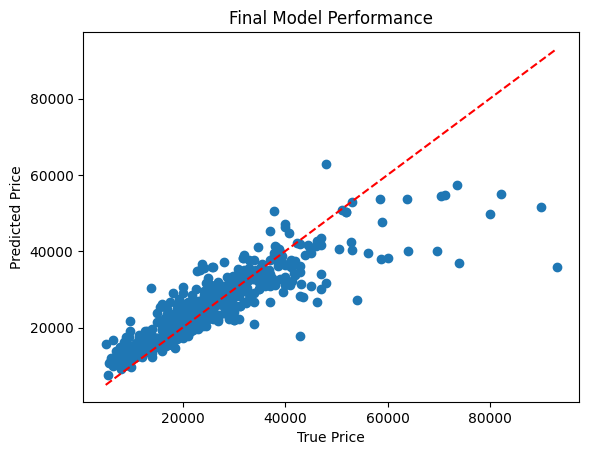

In [75]:
plt.scatter(y_test, y_test_pred_rs)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Final Model Performance")
plt.show()

## 5.4 Feature importances

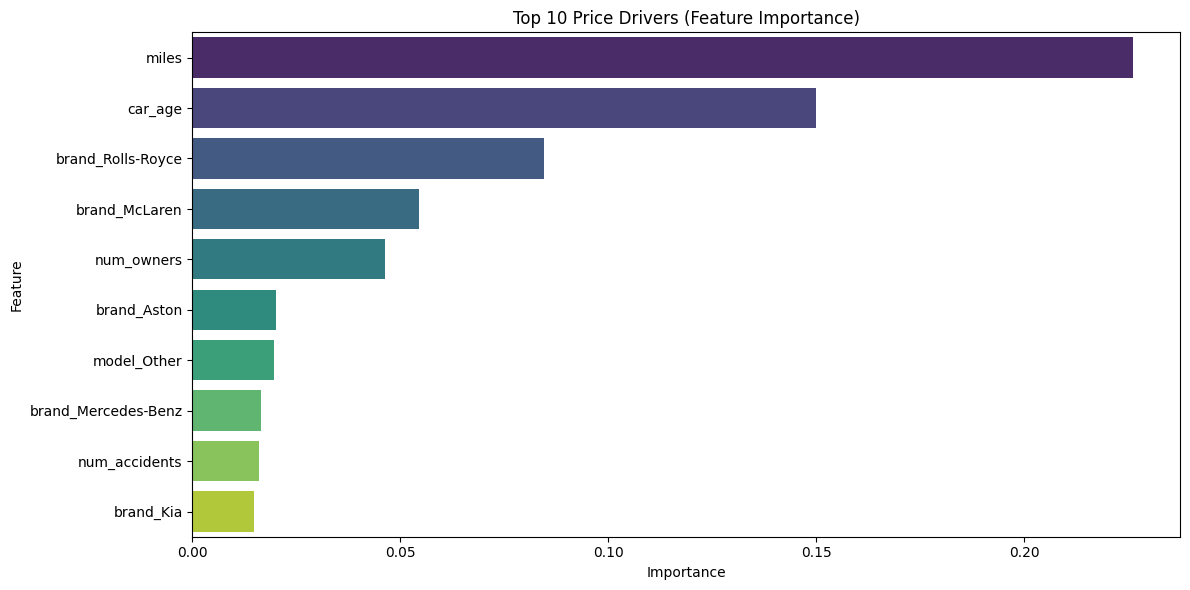

In [76]:

# Feature importances
importances = best_rf.named_steps["model"].feature_importances_

features = X_train.columns

# Create a DataFrame for visualization
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Price Drivers (Feature Importance)')
plt.tight_layout()
plt.show()

Feature importance analysis shows that mileage and vehicle age are the most influential factors in predicting car prices, while num_accidents has a relatively minor impact.

Following our optimization, the Feature Importance analysis reveals that Mileage and Car Age are the two most significant factors, accounting for nearly 38% of the model's decision. We also observe a strong 'Luxury Effect', where prestigious brands like Rolls-Royce and McLaren heavily influence the price. Additionally, the Number of Owners remains a key indicator of vehicle value and trust."

In [77]:
feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

,Feature,Importance
0,miles,0.226
1,car_age,0.150
38,brand_Rolls-Royce,0.085
31,brand_McLaren,0.054
3,num_owners,0.046
5,brand_Aston,0.020
93,model_Other,0.020
32,brand_Mercedes-Benz,0.016
2,num_accidents,0.016
24,brand_Kia,0.015
